In [1]:
from math import pi

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
%matplotlib inline

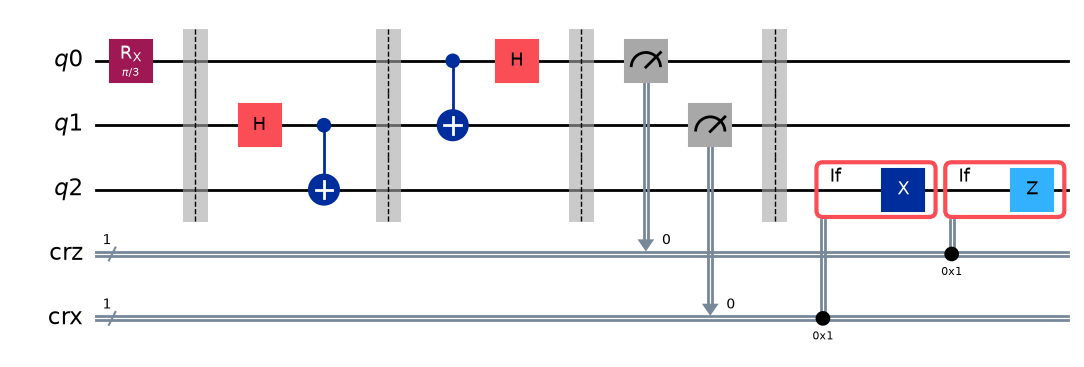

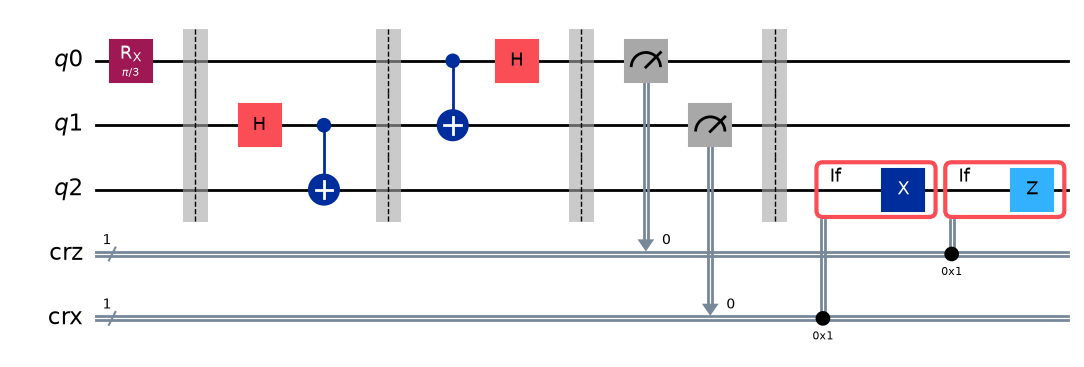

In [2]:
# initialize 3-qubit circuit with named registers
q0 = QuantumRegister(1, name="q0") # Olivia's source qubit to teleport
q1 = QuantumRegister(1, name="q1") # middle qubit sent to Olivia (half of Bell state pair)
q2 = QuantumRegister(1, name="q2") # Barron's destination qubit (half of Bell state pair)

crz = ClassicalRegister(1, name="crz") # Olivia's measurement of her source qubit
crx = ClassicalRegister(1, name="crx") # Olivia's measurement of middle qubit (half of Bell state pair)

circuit = QuantumCircuit(q0, q1, q2, crz, crx)

# initialize Olivia's qubit (quantum state to teleport)
circuit.rx(pi/3, q0)
circuit.barrier()

# create Bell state pair
circuit.h(q1)
circuit.cx(q1, q2)
circuit.barrier()

# Olivia performs Bell state measurement
circuit.cx(q0, q1)
circuit.h(q0)
circuit.barrier()
circuit.measure(q0, crz)
circuit.measure(q1, crx)
circuit.barrier()

# Barron transforms his qubit based on measurement results
# circuit.x(q2).c_if(crx, 1)  # apply X gate if cr_x is 1
with circuit.if_test((crx, 1)):
  circuit.x(q2)  # apply X gate if cr_x is 1
with circuit.if_test((crz, 1)):
  circuit.z(q2)  # apply Z gate if cr_z is 1

circuit.draw(output='mpl')

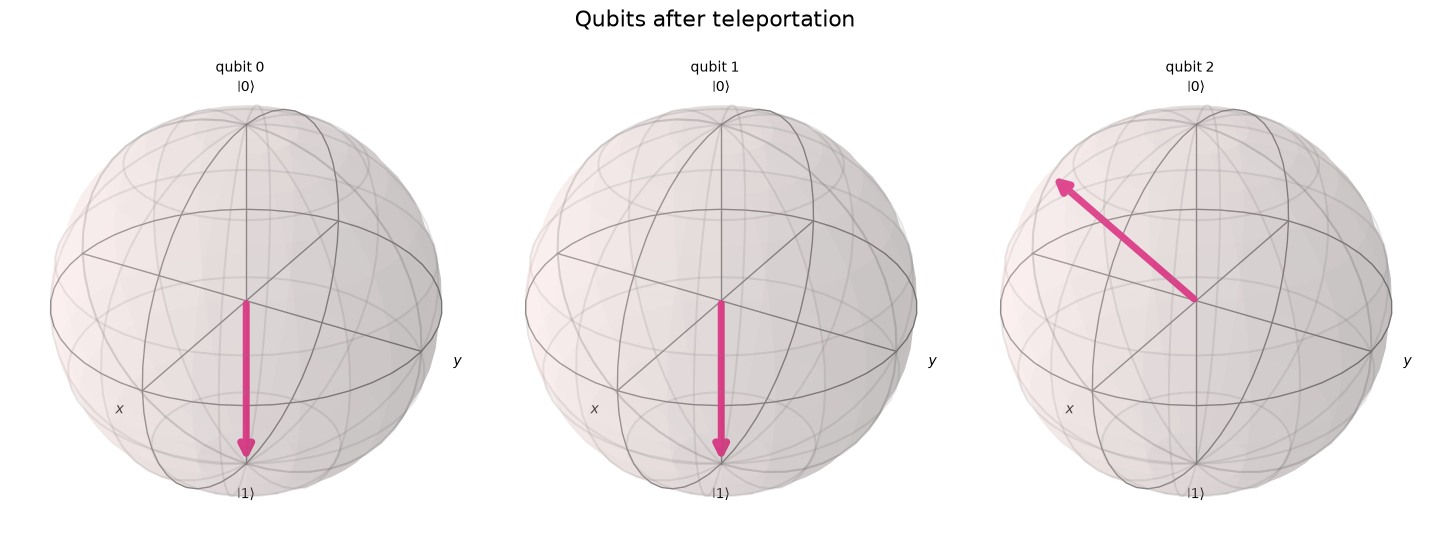

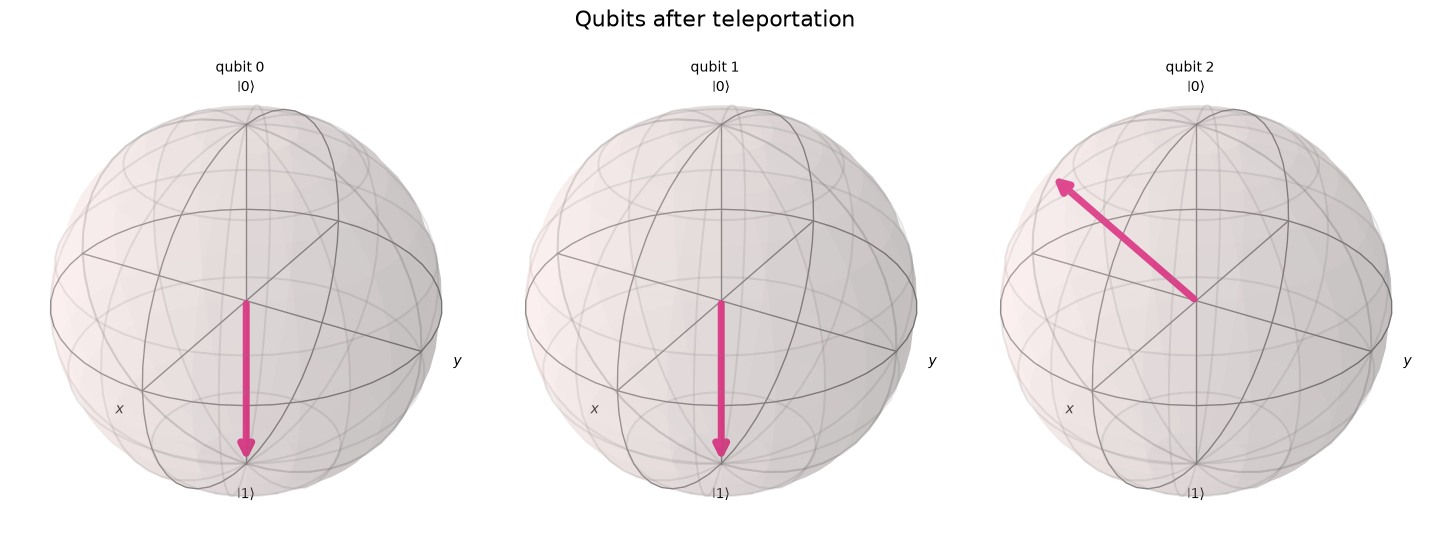

In [3]:
# Statevector simulation of the teleportation circuit
statevector_circuit = QuantumCircuit(3, 2)

statevector_circuit.rx(pi / 3, 0)
statevector_circuit.h(1)
statevector_circuit.cx(1, 2)

statevector_circuit.cx(0, 1)
statevector_circuit.h(0)
statevector_circuit.measure(0, 0)
statevector_circuit.measure(1, 1)

with statevector_circuit.if_test((1, 1)):
    statevector_circuit.x(2)

with statevector_circuit.if_test((0, 1)):
    statevector_circuit.z(2)

statevector_circuit.save_statevector()

simulator = AerSimulator(method="statevector")
compiled_circuit = transpile(statevector_circuit, simulator)

result = simulator.run(compiled_circuit).result()
statevector = result.data(0)["statevector"]

plot_bloch_multivector(
    statevector,
    title="Qubits after teleportation",
)

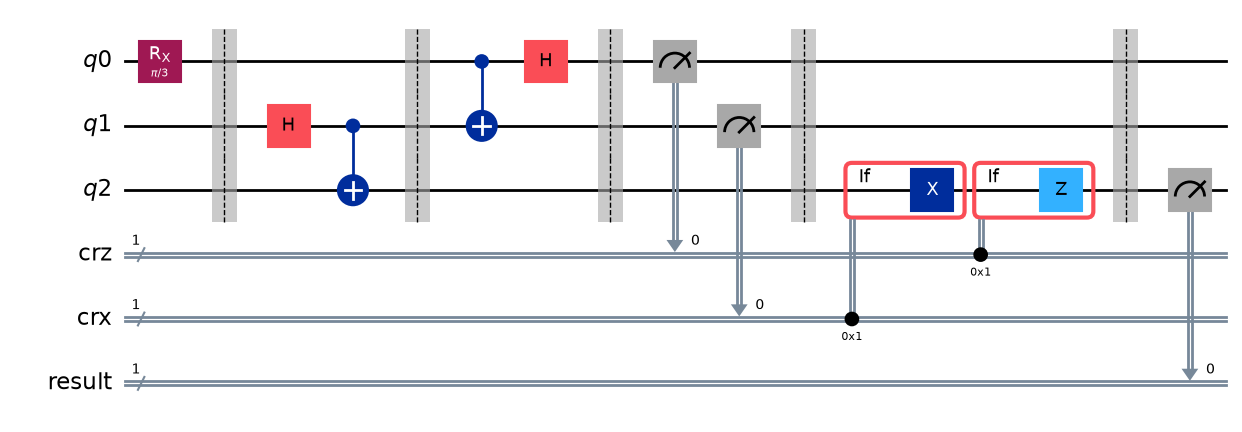

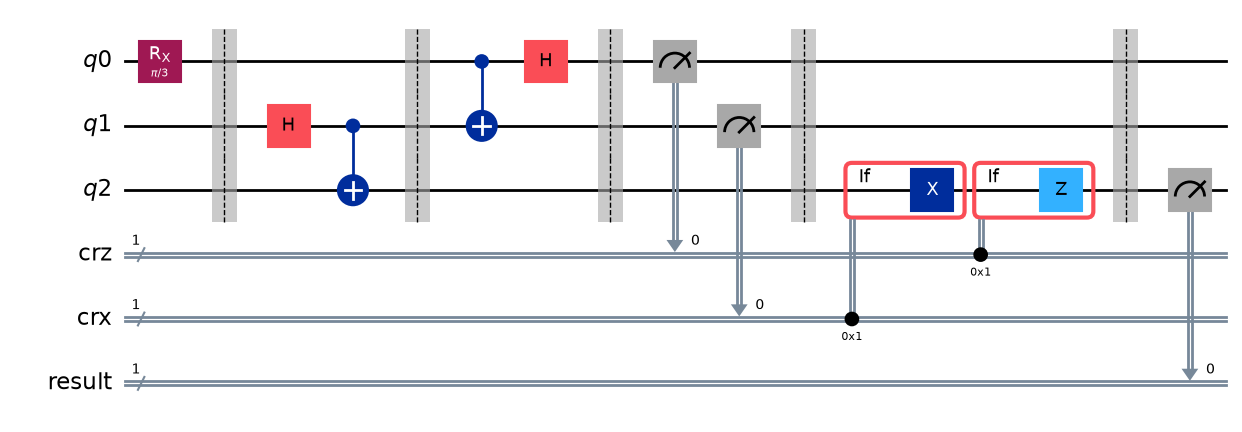

In [4]:
# Add a final measurement of Barron's qubit
cr_result = ClassicalRegister(1, name="result")
circuit.add_register(cr_result)

circuit.barrier()
circuit.measure(2, cr_result[0])

circuit.draw(output="mpl")

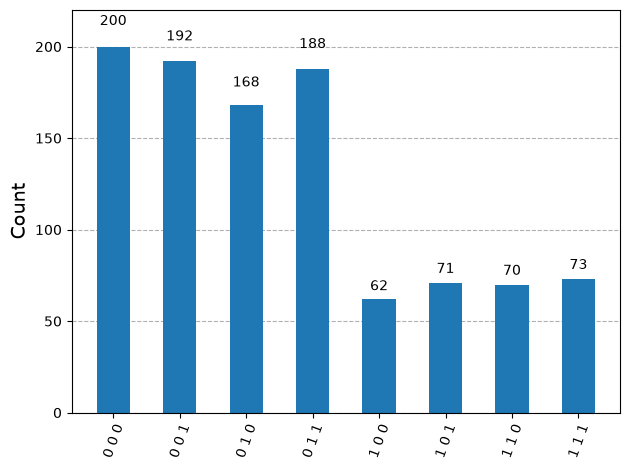

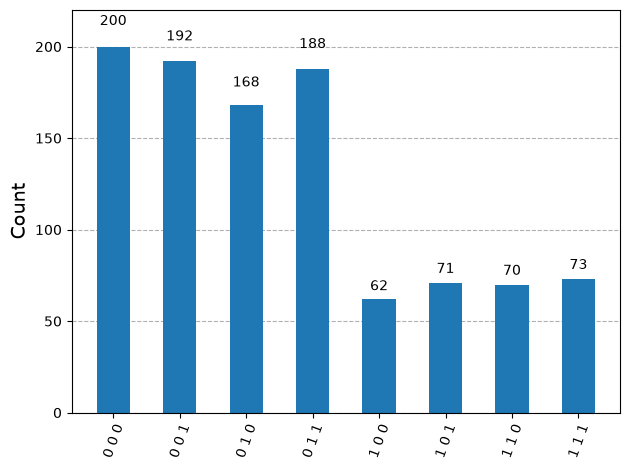

In [5]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)

result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts(compiled_circuit)

plot_histogram(counts)

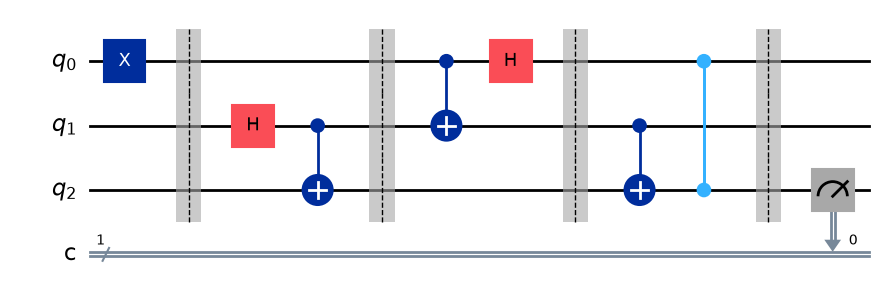

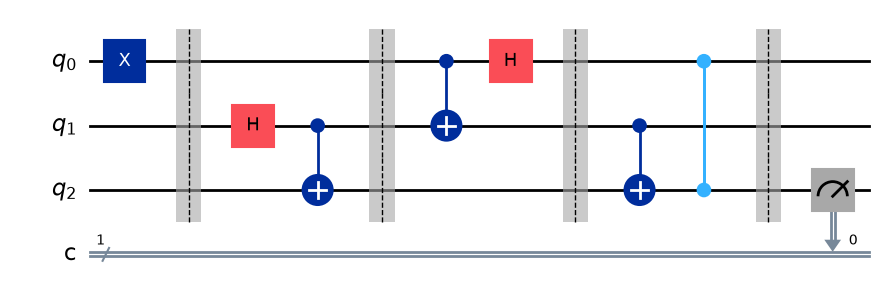

In [7]:
# quantum teleportation circuit using deferred measurement
circuit_def = QuantumCircuit(3, 1)

# initialize Olivia's qubit (quantum state to teleport)
circuit_def.x(0)
circuit_def.barrier()

# create Bell state pair
circuit_def.h(1)
circuit_def.cx(1, 2)
circuit_def.barrier()

# Olivia performs Bell state measurement
circuit_def.cx(0, 1)
circuit_def.h(0)
circuit_def.barrier()

# apply conditional operations on Barron's qubit
circuit_def.cx(1, 2)
circuit_def.cz(0, 2)
circuit_def.barrier()

# measure Barron's destination qubit
circuit_def.measure(2, 0)

circuit_def.draw(output='mpl')

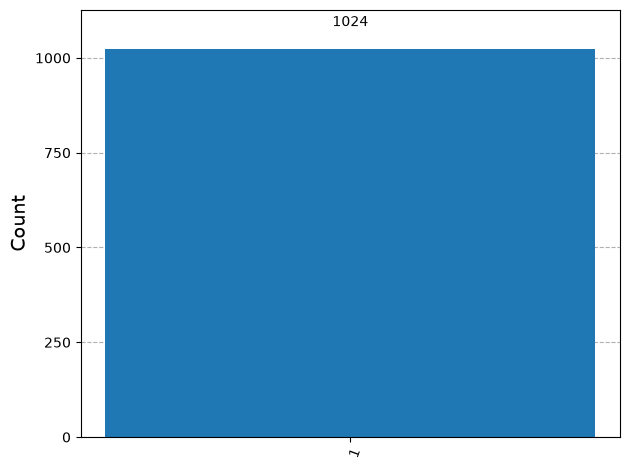

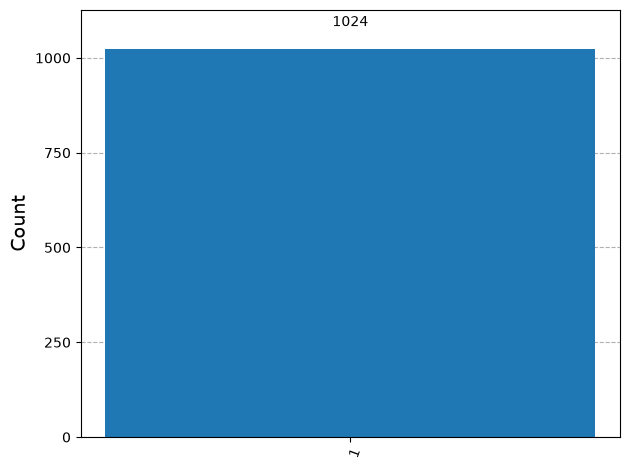

In [8]:
simulator = AerSimulator()
compiled_circuit_def = transpile(circuit_def, simulator)

result_def = simulator.run(compiled_circuit_def, shots=1024).result()
counts_def = result_def.get_counts(compiled_circuit_def)

plot_histogram(counts_def)